# Uso de GPU

In [22]:
import tensorflow as tf

print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

if gpus:
    for i, g in enumerate(gpus):
        details = tf.config.experimental.get_device_details(g)
        print(f"GPU {i} details:", details)
else:
    print("Nenhuma GPU visível para o TensorFlow.")

I0000 00:00:1780078757.354344 1242472 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.21.0
Built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU 0 details: {'compute_capability': (8, 9), 'device_name': 'NVIDIA GeForce RTX 4090'}
GPU 1 details: {'compute_capability': (8, 9), 'device_name': 'NVIDIA GeForce RTX 4090'}


# Análise demográfica

In [23]:
import pandas as pd

df_ext = pd.read_csv("image_data_sMCI_pMCI_extremos.csv")

# 1 linha por paciente (metadados do conjunto)
pt = (
    df_ext.sort_values(["ID_PT", "MRI_DATE", "ID_IMG"])
    .groupby("ID_PT", as_index=False)
    .agg(
        GROUP=("GROUP", "first"),
        SEX=("SEX", "first"),
        n_linhas=("ID_IMG", "size"),
    )
)

# conjuntos = pacientes com exatamente 3 linhas
pt = pt[pt["n_linhas"] == 3].copy()
pt["n_conjuntos"] = 1  # 1 conjunto por paciente válido

# --- totais ---
n_conjuntos_total = len(pt)
n_linhas_total = int(pt["n_linhas"].sum())
print("Conjuntos (pacientes com 3 linhas):", n_conjuntos_total)
print("Linhas totais:", n_linhas_total)
print("Checagem linhas/3:", n_linhas_total / 3)

# --- por GROUP ---
print("\nPor GROUP:")
print(pt["GROUP"].value_counts().sort_index())
# ou só contagem de conjuntos:
# print(pt.groupby("GROUP")["n_conjuntos"].sum())

# --- por SEX ---
print("\nPor SEX:")
print(pt["SEX"].value_counts().sort_index())

# --- GROUP × SEX ---
print("\nGROUP × SEX:")
print(pd.crosstab(pt["GROUP"], pt["SEX"], margins=True))

Conjuntos (pacientes com 3 linhas): 525
Linhas totais: 1575
Checagem linhas/3: 525.0

Por GROUP:
GROUP
pMCI    128
sMCI    397
Name: count, dtype: int64

Por SEX:
SEX
F    222
M    303
Name: count, dtype: int64

GROUP × SEX:
SEX      F    M  All
GROUP               
pMCI    54   74  128
sMCI   168  229  397
All    222  303  525


In [24]:
df_ext.groupby("GROUP")["ID_PT"].nunique()

GROUP
pMCI    128
sMCI    397
Name: ID_PT, dtype: int64

In [25]:
dist_pacientes = (
    df_ext.drop_duplicates(subset=["ID_PT", "GROUP"])
    .groupby(["GROUP", "SEX"])["ID_PT"]
    .nunique()
    .unstack(fill_value=0)
)

dist_pacientes

SEX,F,M
GROUP,,
pMCI,54,74
sMCI,168,229


In [26]:
pts = df_ext.groupby(["GROUP", "ID_PT"], as_index=False)["AGE"].min()

for g in ["sMCI", "pMCI"]:
    a = pts.loc[pts["GROUP"] == g, "AGE"]
    print(
        f"{g}: n={a.count()}, "
        f"min={a.min():.1f}, max={a.max():.1f}, "
        f"media={a.mean():.2f}, desvio={a.std():.2f}"
    )

sMCI: n=397, min=55.0, max=91.0, media=73.52, desvio=7.48
pMCI: n=128, min=57.0, max=89.0, media=75.04, desvio=7.01


In [27]:
adnimerge = pd.read_csv("csvs/adnimerged.csv")
df_ext = pd.read_csv("image_data_sMCI_pMCI_extremos.csv")

cols = ["ID_IMG", "MMSE_SCORE", "CDR_GLOBAL", "ADAS_SCORE", "FAQ_SCORE"]

adni_sub = adnimerge.loc[:, cols].copy()
adni_sub["ID_IMG"] = adni_sub["ID_IMG"].astype(str).str.strip()
adni_sub = adni_sub.drop_duplicates(subset=["ID_IMG"], keep="last")

df_ext["ID_IMG"] = df_ext["ID_IMG"].astype(str).str.strip()
df_ext = df_ext.merge(adni_sub, on="ID_IMG", how="left", validate="many_to_one")

In [28]:
pts = (
    df_ext.sort_values(["GROUP", "ID_PT", "MRI_DATE"])
    .drop_duplicates(subset=["GROUP", "ID_PT"], keep="first")
)

pts.groupby("GROUP")[["MMSE_SCORE", "FAQ_SCORE", "CDR_GLOBAL", "ADAS_SCORE"]].agg(["mean", "std", "count"])

MMSE_SCORE                 FAQ_SCORE                 CDR_GLOBAL  \
            mean       std count      mean       std count       mean   
GROUP                                                                   
pMCI   26.039062  2.249768   128  6.453125  4.619131   128   0.507812   
sMCI   27.758186  1.822132   397  2.503778  3.573628   397   0.497481   

                      ADAS_SCORE                  
            std count       mean       std count  
GROUP                                             
pMCI   0.062253   128  14.382891  5.055354   128  
sMCI   0.035444   397   9.491788  3.917522   397

# Modelagem

Nested CV + SVM L1 + downsampling. Seleção por split: **corr/var** (`USE_CORR_VAR`) → **SelectKBest** (`USE_SELECT_KBEST`, `K_BEST_GRID`) → scaler (`SCALER`) → SVM.


In [ ]:
# Funções compartilhadas — nested CV 5×5 + XGBoost + downsampling (só no treino)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler, StandardScaler
from xgboost import XGBClassifier

METRIC_COLS = [
    "auc", "auc_pr", "bal_acc", "mcc",
    "sens_pMCI", "spec_sMCI", "prec_pMCI", "f1_pMCI",
]
CLASS_NAMES = {0: "sMCI", 1: "pMCI"}
SEED = 42
K_OUT, K_IN = 5, 5
C_GRID = [0.01, 0.05, 0.1, 0.2, 0.3]  # learning_rate (coluna best_C no output)
MAX_DEPTH = 4
N_ESTIMATORS = 200
SUBSAMPLE = 0.8
COLSAMPLE_BYTREE = 0.8
REG_LAMBDA = 1.0
MIN_CHILD_WEIGHT = 1.0
CORR_THR = 0.95
VAR_THR = 0.01
USE_CORR_VAR = False         # correlação + variância por split
USE_SELECT_KBEST = False      # SelectKBest (após corr/var) por split
K_BEST_GRID = [30, 50, 100, 200]  # tunado no CV interno; ignorado se USE_SELECT_KBEST=False
SCALER = "standard"           # "standard" | "robust"
CLASS_WEIGHT = None           # None ou "balanced" (redundante com downsampling)
USE_DOWNSAMPLE = True         # balanceia sMCI/pMCI no treino de cada split
TUNE_THRESHOLD = True         # Youden (tpr−fpr) no CV interno → melhora bal_acc vs limiar 0.5
SCORE_THRESHOLD = 0.5         # limiar em P(pMCI) quando TUNE_THRESHOLD=False


def fold_metrics(y_true, scores, pred) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "auc": float(roc_auc_score(y_true, scores)),
        "auc_pr": float(average_precision_score(y_true, scores)),
        "bal_acc": float(balanced_accuracy_score(y_true, pred)),
        "mcc": float(matthews_corrcoef(y_true, pred)),
        "sens_pMCI": float(tp / (tp + fn)) if (tp + fn) else float("nan"),
        "spec_sMCI": float(tn / (tn + fp)) if (tn + fp) else float("nan"),
        "prec_pMCI": float(precision_score(y_true, pred, pos_label=1, zero_division=0)),
        "f1_pMCI": float(f1_score(y_true, pred, pos_label=1, zero_division=0)),
    }


def _scale_pos_weight(y_fit) -> float:
    if CLASS_WEIGHT != "balanced" or USE_DOWNSAMPLE:
        return 1.0
    y = np.asarray(y_fit, dtype=int)
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    if n_pos == 0:
        return 1.0
    return float(n_neg / n_pos)


def clf(C: float, y_fit=None) -> XGBClassifier:
    return XGBClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        learning_rate=C,
        min_child_weight=MIN_CHILD_WEIGHT,
        subsample=SUBSAMPLE,
        colsample_bytree=COLSAMPLE_BYTREE,
        reg_lambda=REG_LAMBDA,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=_scale_pos_weight(y_fit),
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )


def model_scores(model, X) -> np.ndarray:
    return model.predict_proba(X)[:, 1]

def downsample_patient_indices(idx, y, seed: int) -> np.ndarray:
    """Mesmo nº de índices sMCI e pMCI no conjunto referenciado por idx."""
    idx = np.asarray(idx)
    rng = np.random.default_rng(seed)
    i0 = idx[y[idx] == 0]
    i1 = idx[y[idx] == 1]
    n = min(len(i0), len(i1))
    pick = np.concatenate([rng.choice(i0, n, replace=False), rng.choice(i1, n, replace=False)])
    rng.shuffle(pick)
    return pick


def train_indices(idx, y, seed: int) -> np.ndarray:
    if USE_DOWNSAMPLE:
        return downsample_patient_indices(idx, y, seed)
    return np.asarray(idx)


def tune_decision_threshold(y_true, scores) -> float:
    """Índice de Youden no CV interno: maximiza sens + spec − 1."""
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    if len(np.unique(y_true)) < 2:
        return 0.0
    fpr, tpr, thr = roc_curve(y_true, scores)
    j = tpr - fpr
    return float(thr[int(np.argmax(j))])


def fit_fold_model(X_fit, y_fit, X_other, keep, C):
    X_fit_sel = apply_column_mask(X_fit, keep)
    X_other_sel = apply_column_mask(X_other, keep)
    X_fit_z, X_other_z = scale_train_val(X_fit_sel, X_other_sel)
    model = clf(C, y_fit)
    model.fit(X_fit_z, y_fit)
    return model, X_fit_z, X_other_z


# --- Correlação + variância (sem SelectKBest) ---
def corr_keep_indices(X: np.ndarray, thr: float) -> np.ndarray:
    xf = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    if xf.shape[0] < 2:
        return np.arange(X.shape[1], dtype=int)
    c = np.corrcoef(xf.T)
    keep: list[int] = []
    for j in range(c.shape[0]):
        if all(not (np.isfinite(c[j, k]) and abs(c[j, k]) > thr) for k in keep):
            keep.append(j)
    return np.asarray(keep, dtype=int)


def var_keep_indices(X: np.ndarray, thr: float) -> np.ndarray:
    xf = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    vt = VarianceThreshold(threshold=thr)
    vt.fit(xf)
    return np.where(vt.get_support())[0]


def corr_var_keep(X_train: np.ndarray, corr_thr: float, var_thr: float) -> np.ndarray:
    """Máscara de colunas: só correlação + variância."""
    if not USE_CORR_VAR:
        return np.arange(X_train.shape[1], dtype=int)
    k_corr = corr_keep_indices(X_train, corr_thr)
    k_var = var_keep_indices(X_train[:, k_corr], var_thr)
    return k_corr[k_var]


# --- SelectKBest exclusivo (requer y; colunas já filtradas por corr/var) ---
def select_kbest_keep(X_train: np.ndarray, y_train: np.ndarray, k: int) -> np.ndarray:
    """Índices locais (0..n_cols-1) das colunas de X_train escolhidas por f_classif."""
    X = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
    n_cols = X.shape[1]
    if n_cols == 0:
        return np.arange(0, dtype=int)
    k = min(int(k), n_cols)
    if k < 1:
        return np.arange(n_cols, dtype=int)
    skb = SelectKBest(score_func=f_classif, k=k)
    skb.fit(X, np.asarray(y_train, dtype=int))
    return np.where(skb.get_support())[0]


def build_column_keep(X_train: np.ndarray, y_train: np.ndarray, k: int) -> np.ndarray:
    """Ordem: corr/var → SelectKBest (opcional) → índices no X original."""
    keep = corr_var_keep(X_train, CORR_THR, VAR_THR)
    if USE_SELECT_KBEST:
        k_local = select_kbest_keep(X_train[:, keep], y_train, k)
        keep = keep[k_local]
    return keep


def apply_column_mask(X: np.ndarray, keep: np.ndarray) -> np.ndarray:
    return X[:, keep]


def _make_scaler():
    if SCALER == "robust":
        return RobustScaler()
    if SCALER == "standard":
        return StandardScaler()
    raise ValueError(f"SCALER inválido: {SCALER!r}")


def scale_train_val(X_fit, X_other):
    scaler = _make_scaler()
    return scaler.fit_transform(X_fit), scaler.transform(X_other)


def _k_grid():
    return K_BEST_GRID if USE_SELECT_KBEST else [0]


def nested_cv_patient_level(
    X, y, test_name: str, *, collect_fold_details: bool = False
):
    """Testes 1 e 2: StratifiedKFold + corr/var + SelectKBest + z-score por split."""
    results = []
    fold_details: list[dict] = []
    outer = StratifiedKFold(K_OUT, shuffle=True, random_state=SEED)
    for fold, (tr, te) in enumerate(outer.split(X, y), start=1):
        best_C, best_k = C_GRID[0], K_BEST_GRID[0]
        best_inner_auc = -1.0
        inner = StratifiedKFold(K_IN, shuffle=True, random_state=SEED + fold)

        for k in _k_grid():
            for C in C_GRID:
                inner_aucs = []
                seed_extra = int(k) if USE_SELECT_KBEST else 0
                for in_tr, in_va in inner.split(X[tr], y[tr]):
                    keep = build_column_keep(X[tr][in_tr], y[tr][in_tr], k)
                    bal = train_indices(
                        in_tr, y[tr], SEED + fold + int(C * 1e4) + seed_extra
                    )
                    X_fit = apply_column_mask(X[tr][bal], keep)
                    X_va = apply_column_mask(X[tr][in_va], keep)
                    X_fit_z, X_va_z = scale_train_val(X_fit, X_va)

                    model = clf(C, y[tr][bal])
                    model.fit(X_fit_z, y[tr][bal])
                    if len(np.unique(y[tr][in_va])) > 1:
                        inner_aucs.append(
                            roc_auc_score(y[tr][in_va], model_scores(model, X_va_z))
                        )

                if inner_aucs and np.mean(inner_aucs) > best_inner_auc:
                    best_inner_auc = float(np.mean(inner_aucs))
                    best_C, best_k = C, k

        keep = build_column_keep(X[tr], y[tr], best_k)
        threshold = SCORE_THRESHOLD
        if TUNE_THRESHOLD:
            inner_scores, inner_y = [], []
            for in_tr, in_va in inner.split(X[tr], y[tr]):
                keep_in = build_column_keep(X[tr][in_tr], y[tr][in_tr], best_k)
                bal_in = train_indices(in_tr, y[tr], SEED + fold + 9000)
                model_in, _, X_va_z = fit_fold_model(
                    X[tr][bal_in], y[tr][bal_in], X[tr][in_va], keep_in, best_C
                )
                inner_scores.append(model_scores(model_in, X_va_z))
                inner_y.append(y[tr][in_va])
            threshold = tune_decision_threshold(
                np.concatenate(inner_y), np.concatenate(inner_scores)
            )

        bal = train_indices(tr, y, SEED + fold)
        model, X_fit_z, X_te_z = fit_fold_model(
            X[bal], y[bal], X[te], keep, best_C
        )
        scores = model_scores(model, X_te_z)
        pred = (scores >= threshold).astype(int)

        row = {
            "test": test_name,
            "fold": fold,
            "best_C": best_C,
            "best_k": int(best_k) if USE_SELECT_KBEST else None,
            "threshold": threshold,
            "n_features": int(len(keep)),
            "n_train_bal": len(bal),
            "n_test": len(te),
            "n_test_pMCI": int(y[te].sum()),
            **fold_metrics(y[te], scores, pred),
        }
        results.append(row)
        if collect_fold_details:
            fold_details.append({
                "fold": fold,
                "best_C": best_C,
                "best_k": best_k,
                "threshold": threshold,
                "y_test": np.asarray(y[te], dtype=int),
                "scores": np.asarray(scores, dtype=float),
                "pred": np.asarray(pred, dtype=int),
                "X_fit_z": X_fit_z,
                "X_te_z": X_te_z,
                "y_fit": np.asarray(y[bal], dtype=int),
            })

    df = pd.DataFrame(results)
    if collect_fold_details:
        return df, fold_details
    return df


# --- Gráficos de diagnóstico (teste externo por fold) ---
def plot_score_histogram(y, scores, *, title="Scores no teste", ax=None, threshold=0.0):
    ax = ax or plt.gca()
    ax.hist(scores[y == 0], bins=25, alpha=0.6, label=CLASS_NAMES[0])
    ax.hist(scores[y == 1], bins=25, alpha=0.6, label=CLASS_NAMES[1])
    ax.axvline(threshold, color="k", linestyle="--", linewidth=1, label=f"limiar {threshold:.3f}")
    ax.set_xlabel("decision_function")
    ax.set_ylabel("pacientes")
    ax.set_title(title)
    ax.legend()
    return ax


def plot_roc_all_folds(fold_details, *, title="ROC — folds externos", ax=None):
    ax = ax or plt.gca()
    for fd in fold_details:
        if len(np.unique(fd["y_test"])) < 2:
            continue
        RocCurveDisplay.from_predictions(
            fd["y_test"], fd["scores"], ax=ax, name=f"fold {fd['fold']}"
        )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8)
    return ax


def plot_pr_all_folds(fold_details, *, title="PR — folds externos", ax=None):
    ax = ax or plt.gca()
    for fd in fold_details:
        if len(np.unique(fd["y_test"])) < 2:
            continue
        PrecisionRecallDisplay.from_predictions(
            fd["y_test"], fd["scores"], ax=ax, name=f"fold {fd['fold']}"
        )
    ax.set_title(title)
    ax.legend(loc="lower left", fontsize=8)
    return ax


def plot_confusion_aggregate(fold_details, *, title="Confusão agregada (teste)", ax=None):
    y_all = np.concatenate([fd["y_test"] for fd in fold_details])
    pred_all = np.concatenate([fd["pred"] for fd in fold_details])
    ax = ax or plt.gca()
    ConfusionMatrixDisplay.from_predictions(
        y_all, pred_all, display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]], ax=ax
    )
    ax.set_title(title)
    return ax


def plot_pca_fold(fd, *, title=None, ax=None):
    pca = PCA(n_components=2, random_state=SEED)
    Z_fit = pca.fit_transform(fd["X_fit_z"])
    Z_te = pca.transform(fd["X_te_z"])
    Z = np.vstack([Z_fit, Z_te])
    y_plot = np.concatenate([fd["y_fit"], fd["y_test"]])

    ax = ax or plt.gca()
    for label in (0, 1):
        m = y_plot == label
        ax.scatter(Z[m, 0], Z[m, 1], alpha=0.5, s=24, label=CLASS_NAMES[label])
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title(title or f"PCA — fold externo {fd['fold']}")
    ax.legend(fontsize=8)
    return ax


def plot_cv_diagnostics(fold_details, test_name, *, hist_fold=1, pca_fold=1):
    fd_hist = next(fd for fd in fold_details if fd["fold"] == hist_fold)
    fd_pca = next(fd for fd in fold_details if fd["fold"] == pca_fold)

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    plot_score_histogram(
        fd_hist["y_test"], fd_hist["scores"],
        title=f"{test_name} — scores (fold {hist_fold}, teste)", ax=axes[0, 0],
    )
    plot_roc_all_folds(fold_details, title=f"{test_name} — ROC", ax=axes[0, 1])
    plot_confusion_aggregate(
        fold_details, title=f"{test_name} — confusão agregada", ax=axes[1, 0],
    )
    plot_pca_fold(fd_pca, title=f"{test_name} — PCA (fold {pca_fold})", ax=axes[1, 1])
    fig.suptitle(test_name, fontsize=12, y=1.02)
    fig.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(6, 5))
    plot_pr_all_folds(fold_details, title=f"{test_name} — PR", ax=ax2)
    fig2.tight_layout()
    plt.show()


def print_summary(df: pd.DataFrame) -> None:
    print(f"\n=== {df['test'].iloc[0]} ===")
    display(df)
    print("\nResumo (média ± desvio entre folds):")
    for col in METRIC_COLS:
        print(f"  {col:12s}: {df[col].mean():.3f} ± {df[col].std():.3f}")


## Teste 1 — média global das 60 linhas (baseline)


In [42]:
# # --- Teste 1: média global das 60 linhas (baseline) ---

# import pandas as pd
# import numpy as np

# # PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/all_features_merge_clean.csv"
# PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/all_features_merge_hippocampus_clean.csv"

# meta = {"ID_PT", "GROUP", "SEX"}
# df = pd.read_csv(PATH).sort_values("ID_PT")
# feat = [c for c in df.columns if c not in meta]

# X, y = [], []
# for _, g in df.groupby("ID_PT", sort=False):
#     # if len(g) != 60:
#     if len(g) != 6:
#         continue
#     X.append(g[feat].to_numpy(float).mean(axis=0))
#     y.append(int(g["GROUP"].iloc[0]))
# X, y = np.vstack(X), np.array(y, dtype=int)
# print(f"Teste 1 | {len(y)} pacientes | dim={X.shape[1]} | sMCI={(y==0).sum()} | pMCI={(y==1).sum()}")

# results_t1, details_t1 = nested_cv_patient_level(
#     X, y, "teste1_media_60linhas", collect_fold_details=True
# )
# print_summary(results_t1)
# plot_cv_diagnostics(details_t1, "teste1_media_60linhas")


## Teste 2 — wide temporal (1 linha/paciente)


Teste 2 | 525 pacientes | dim=90

=== teste2_wide_temporal ===


,test,fold,best_C,best_k,threshold,n_features,n_train_bal,n_test,n_test_pMCI,auc,auc_pr,bal_acc,mcc,sens_pMCI,spec_sMCI,prec_pMCI,f1_pMCI
0,teste2_wide_temporal,1,0.1,None,0.049467,90,204,105,26,0.695229,0.443045,0.649464,0.264476,0.615385,0.683544,0.390244,0.477612
1,teste2_wide_temporal,2,0.1,None,-0.114266,90,204,105,26,0.786758,0.615925,0.733447,0.403949,0.884615,0.582278,0.410714,0.560976
2,teste2_wide_temporal,3,0.1,None,-0.038242,90,204,105,26,0.837390,0.660885,0.751704,0.445388,0.769231,0.734177,0.487805,0.597015
3,teste2_wide_temporal,4,0.1,None,0.066475,90,206,105,25,0.765500,0.517543,0.703750,0.352949,0.720000,0.687500,0.418605,0.529412
4,teste2_wide_temporal,5,0.1,None,-0.098952,90,206,105,25,0.713500,0.550807,0.647500,0.251303,0.720000,0.575000,0.346154,0.467532



Resumo (média ± desvio entre folds):
  auc         : 0.760 ± 0.057
  auc_pr      : 0.558 ± 0.085
  bal_acc     : 0.697 ± 0.048
  mcc         : 0.344 ± 0.085
  sens_pMCI   : 0.742 ± 0.098
  spec_sMCI   : 0.653 ± 0.070
  prec_pMCI   : 0.411 ± 0.051
  f1_pMCI     : 0.527 ± 0.055


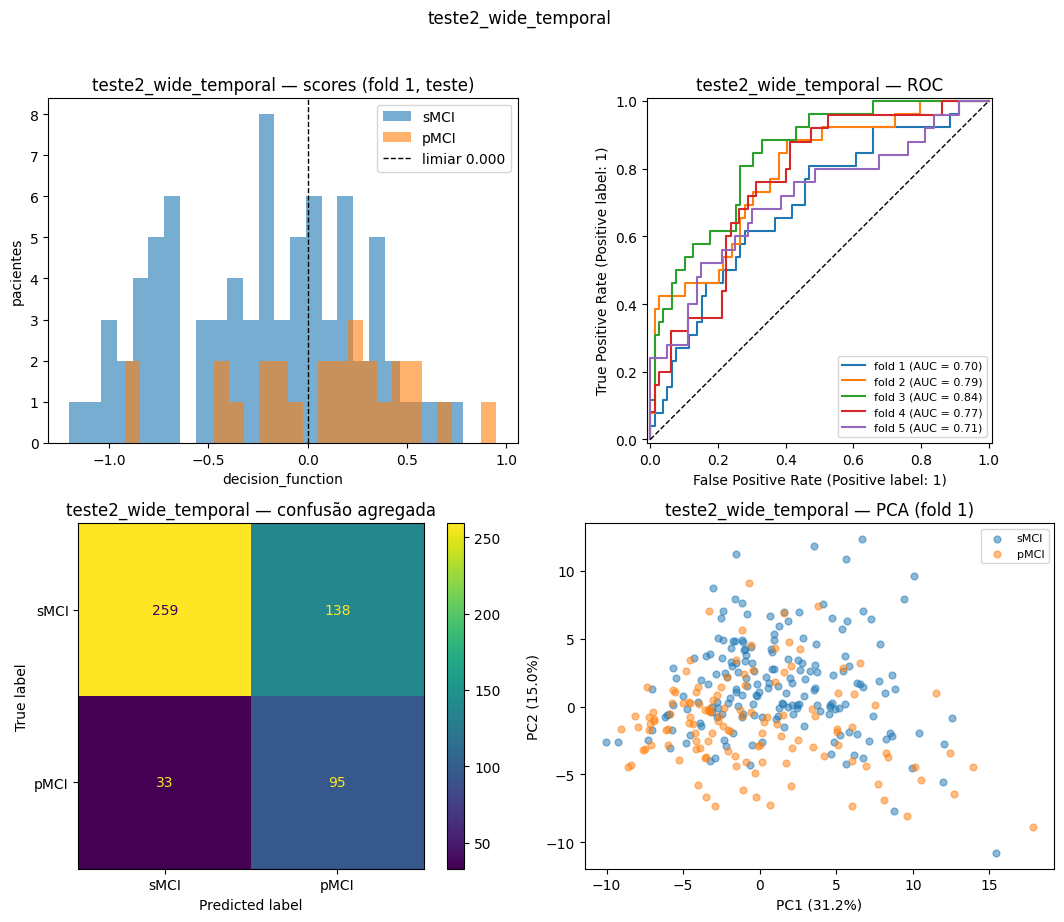

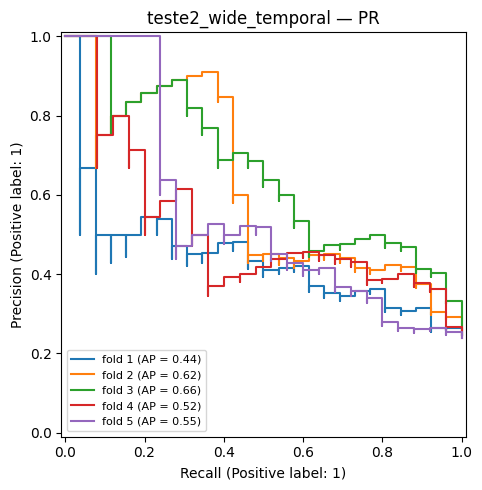

In [10]:
# --- Teste 2: 1 linha/paciente; ROI × T1/T2/T3 nas colunas ---
# PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/all_features_patient_temporal.csv"
PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/features_displacement_article_hippocampus_temporal.csv"

meta = {"ID_PT", "GROUP", "SEX"}
df = pd.read_csv(PATH)
X = df.drop(columns=meta).to_numpy(float)
y = df["GROUP"].to_numpy(int)
print(f"Teste 2 | {len(y)} pacientes | dim={X.shape[1]}")

results_t2, details_t2 = nested_cv_patient_level(
    X, y, "teste2_wide_temporal", collect_fold_details=True
)

print_summary(results_t2)
plot_cv_diagnostics(details_t2, "teste2_wide_temporal")


## Teste 2c — referência rápida (L1 + SVM linear)

Pipeline de **5-fold estratificado** (sem nested CV): `StandardScaler` → `SelectFromModel` (LogReg L1, `C=0.05`, `class_weight='balanced'`) → `SVC` linear (`decision_function`, limiar 0). Compara com o nested CV do Teste 2.

No arquivo completo de DVF (`features_displacement_hippocampus_temporal.csv`, 648 colunas T1/T2/T3) reproduz ~**AUC 0,79** e **bal_acc 0,75**. Deltas explícitos (T1+Δ12+Δ13) tendem a piorar vs. wide T1/T2/T3.

Teste 2c | 525 pacientes | dim=90

=== teste2c_l1_svm ===


,test,fold,best_C,best_k,threshold,n_features,n_train_bal,n_test,n_test_pMCI,auc,auc_pr,bal_acc,mcc,sens_pMCI,spec_sMCI,prec_pMCI,f1_pMCI
0,teste2c_l1_svm,1,0.05,11,0.0,11,420,105,26,0.744401,0.567775,0.655550,0.282895,0.576923,0.734177,0.416667,0.483871
1,teste2c_l1_svm,2,0.05,10,0.0,10,420,105,26,0.749757,0.599853,0.738802,0.426643,0.730769,0.746835,0.487179,0.584615
2,teste2c_l1_svm,3,0.05,11,0.0,11,420,105,26,0.813535,0.605179,0.776777,0.514680,0.730769,0.822785,0.575758,0.644068
3,teste2c_l1_svm,4,0.05,11,0.0,11,420,105,25,0.757500,0.514161,0.691250,0.329204,0.720000,0.662500,0.400000,0.514286
4,teste2c_l1_svm,5,0.05,13,0.0,13,420,105,25,0.758000,0.549411,0.736250,0.410792,0.760000,0.712500,0.452381,0.567164



Resumo (média ± desvio entre folds):
  auc         : 0.765 ± 0.028
  auc_pr      : 0.567 ± 0.038
  bal_acc     : 0.720 ± 0.047
  mcc         : 0.393 ± 0.090
  sens_pMCI   : 0.704 ± 0.072
  spec_sMCI   : 0.736 ± 0.058
  prec_pMCI   : 0.466 ± 0.070
  f1_pMCI     : 0.559 ± 0.062


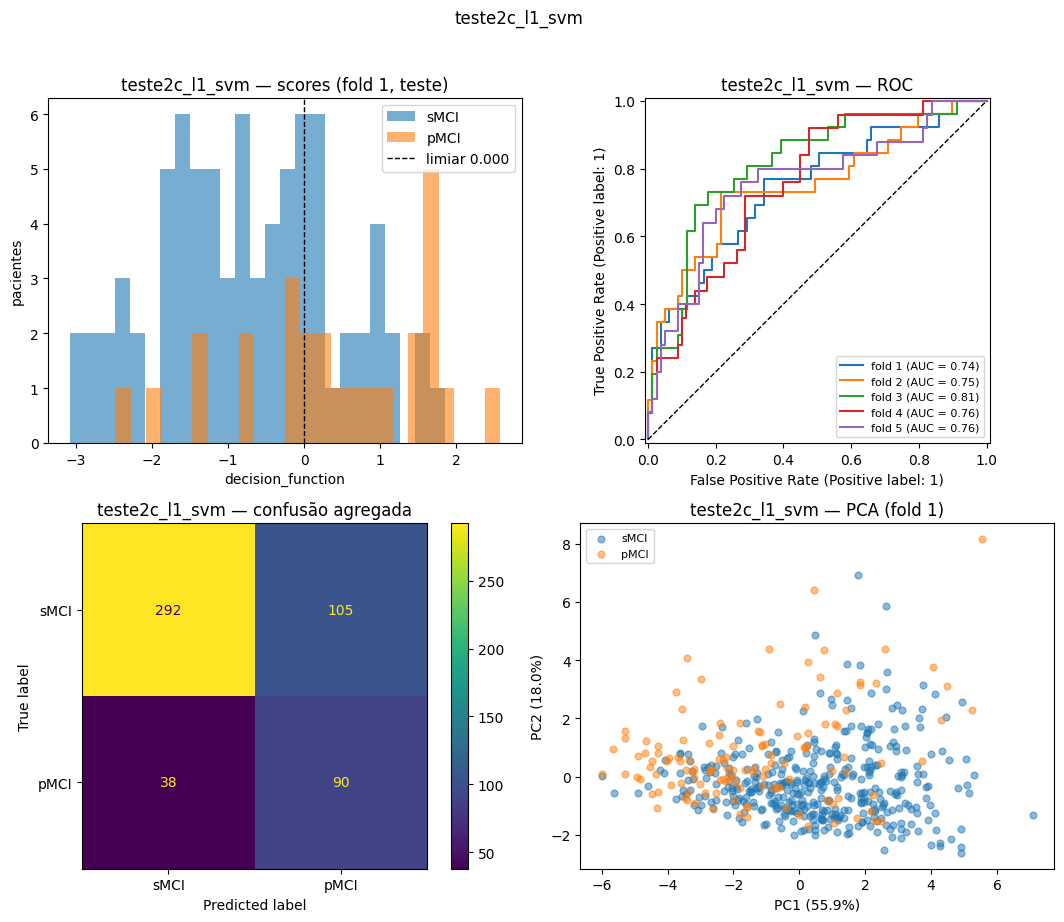

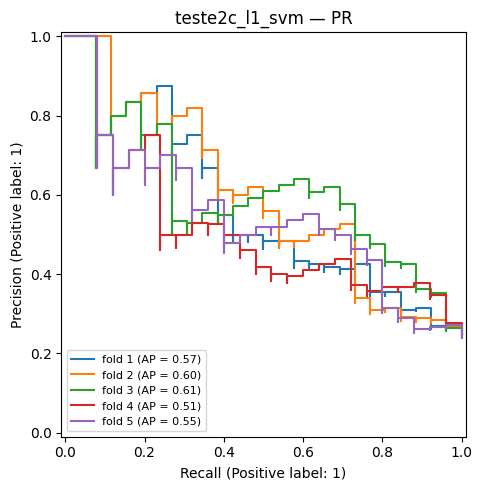

In [17]:
# --- Teste 2c: L1 multivariado + SVM (referência, 5-fold) ---
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

PATH_T2C = "csvs/abordagem_4_sMCI_pMCI_extremos/all_features_article_temporal_hippocampus.csv"
L1_C = 0.05
TEST_NAME_T2C = "teste2c_l1_svm"

df_t2c = pd.read_csv(PATH_T2C)
feat_t2c = [c for c in df_t2c.columns if "_T1_" in c or "_T2_" in c or "_T3_" in c]
X_t2c = df_t2c[feat_t2c].to_numpy(float)
y_t2c = df_t2c["GROUP"].to_numpy(int)
print(f"Teste 2c | {len(y_t2c)} pacientes | dim={X_t2c.shape[1]}")

cv_t2c = StratifiedKFold(n_splits=K_OUT, shuffle=True, random_state=SEED)
results_t2c: list[dict] = []
fold_details_t2c: list[dict] = []

for fold, (tr, te) in enumerate(cv_t2c.split(X_t2c, y_t2c), start=1):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_t2c[tr])
    X_te = scaler.transform(X_t2c[te])
    selector = SelectFromModel(
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=L1_C,
            class_weight="balanced",
            random_state=SEED,
        )
    )
    X_tr_sel = selector.fit_transform(X_tr, y_t2c[tr])
    X_te_sel = selector.transform(X_te)
    n_sel = int(X_tr_sel.shape[1])
    clf = SVC(kernel="linear", class_weight="balanced", random_state=SEED)
    clf.fit(X_tr_sel, y_t2c[tr])
    scores = clf.decision_function(X_te_sel)
    pred = (scores >= 0).astype(int)

    results_t2c.append({
        "test": TEST_NAME_T2C,
        "fold": fold,
        "best_C": L1_C,
        "best_k": n_sel,
        "threshold": 0.0,
        "n_features": n_sel,
        "n_train_bal": len(tr),
        "n_test": len(te),
        "n_test_pMCI": int(y_t2c[te].sum()),
        **fold_metrics(y_t2c[te], scores, pred),
    })
    fold_details_t2c.append({
        "fold": fold,
        "best_C": L1_C,
        "best_k": n_sel,
        "threshold": 0.0,
        "y_test": np.asarray(y_t2c[te], dtype=int),
        "scores": np.asarray(scores, dtype=float),
        "pred": np.asarray(pred, dtype=int),
        "X_fit_z": np.asarray(X_tr_sel, dtype=float),
        "X_te_z": np.asarray(X_te_sel, dtype=float),
        "y_fit": np.asarray(y_t2c[tr], dtype=int),
    })

results_t2c_df = pd.DataFrame(results_t2c)
print_summary(results_t2c_df)
plot_cv_diagnostics(fold_details_t2c, TEST_NAME_T2C)


## Teste 2b — baseline + dinâmica

Para cada atributo (hipocampo L/R × feature): **T₁** + variação temporal. O Teste 3 com *slopes* isolados perde o baseline (AUC ~0,63); combinar T₁ com Δ ou slope recupera parte do sinal.

`REPRESENTATION`: `"t1_d21_d31"` | `"t1_rd21_rd31"` | `"t1_slope13"` | `"t1_delta13"` | `"t1_slope13_delta13"`.


Teste 2b | 525 pacientes | dim=60 | repr=t1_slope13

=== teste2b_t1_slope13 ===


,test,fold,best_C,best_k,threshold,n_features,n_train_bal,n_test,n_test_pMCI,auc,auc_pr,bal_acc,mcc,sens_pMCI,spec_sMCI,prec_pMCI,f1_pMCI
0,teste2b_t1_slope13,1,0.1,None,0.029099,60,204,105,26,0.647517,0.365787,0.623905,0.219248,0.576923,0.670886,0.365854,0.447761
1,teste2b_t1_slope13,2,0.1,None,-0.029088,60,204,105,26,0.762902,0.570792,0.707400,0.359403,0.769231,0.645570,0.416667,0.540541
2,teste2b_t1_slope13,3,0.1,None,-0.226675,60,204,105,26,0.794547,0.597306,0.701315,0.347589,0.807692,0.594937,0.396226,0.531646
3,teste2b_t1_slope13,4,0.1,None,-0.027813,60,206,105,25,0.804500,0.549685,0.738750,0.407213,0.840000,0.637500,0.420000,0.560000
4,teste2b_t1_slope13,5,0.1,None,-0.065613,60,206,105,25,0.700500,0.481545,0.612500,0.193649,0.600000,0.625000,0.333333,0.428571



Resumo (média ± desvio entre folds):
  auc         : 0.742 ± 0.067
  auc_pr      : 0.513 ± 0.093
  bal_acc     : 0.677 ± 0.055
  mcc         : 0.305 ± 0.094
  sens_pMCI   : 0.719 ± 0.122
  spec_sMCI   : 0.635 ± 0.028
  prec_pMCI   : 0.386 ± 0.037
  f1_pMCI     : 0.502 ± 0.059


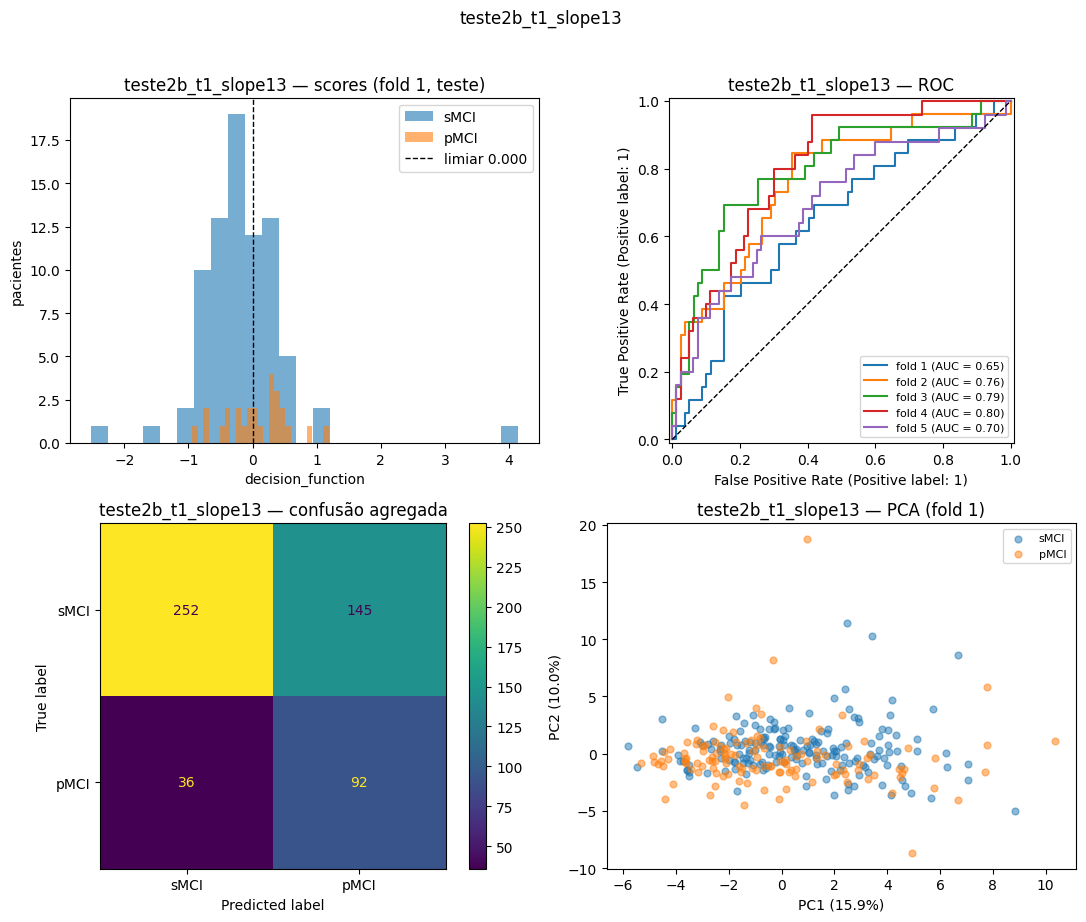

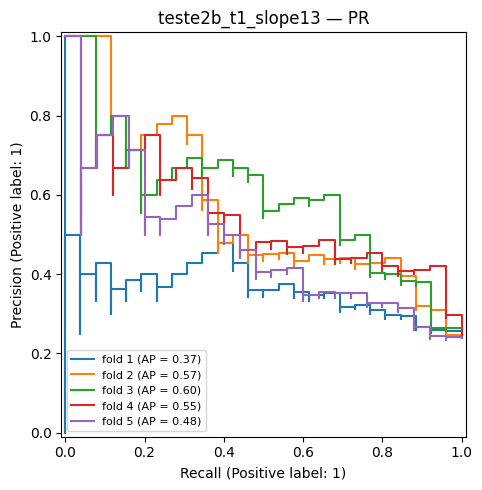

In [11]:
# --- Teste 2b: baseline (T1) + dinâmica (Δ ou slope anualizado) ---
import re

PATH_TEMPORAL = "csvs/abordagem_4_sMCI_pMCI_extremos/features_displacement_article_hippocampus_temporal.csv"
PATH_DELTAS = "csvs/abordagem_4_sMCI_pMCI_extremos/features_displacement_article_hippocampus_temporal_deltas.csv"
REPRESENTATION = "t1_slope13"  # melhor compromisso baseline+dinâmica nos dados atuais

meta = {"ID_PT", "GROUP", "SEX"}
_TRIPLET = re.compile(r"^(hippocampus_[LR])_(T[123])_(.+)$")


def build_baseline_dynamics(
    df_temporal: pd.DataFrame,
    df_deltas: pd.DataFrame | None,
    mode: str,
    *,
    rel_eps: float = 1e-6,
) -> tuple[pd.DataFrame, list[str]]:
    feat_cols = [c for c in df_temporal.columns if c not in meta]
    triplets: dict[tuple[str, str], dict[str, str]] = {}
    for col in feat_cols:
        m = _TRIPLET.match(col)
        if not m:
            continue
        triplets.setdefault((m.group(1), m.group(3)), {})[m.group(2)] = col

    rows: list[dict[str, float]] = []
    for _, row in df_temporal.iterrows():
        out: dict[str, float] = {}
        for (roi_side, feat), tmap in triplets.items():
            if not all(t in tmap for t in ("T1", "T2", "T3")):
                continue
            t1 = float(row[tmap["T1"]])
            t2 = float(row[tmap["T2"]])
            t3 = float(row[tmap["T3"]])
            base = f"{roi_side}_{feat}"
            if mode == "t1_d21_d31":
                out[f"{base}_T1"] = t1
                out[f"{base}_d21"] = t2 - t1
                out[f"{base}_d31"] = t3 - t1
            elif mode == "t1_rd21_rd31":
                denom = abs(t1) + rel_eps
                out[f"{base}_T1"] = t1
                out[f"{base}_rd21"] = (t2 - t1) / denom
                out[f"{base}_rd31"] = (t3 - t1) / denom
            elif mode in {"t1_slope13", "t1_delta13", "t1_slope13_delta13"}:
                if df_deltas is None:
                    raise ValueError(f"mode={mode!r} requer PATH_DELTAS")
                out[f"{base}_T1"] = t1
                if mode in {"t1_slope13", "t1_slope13_delta13"}:
                    c = f"{roi_side}_slope13_{feat}"
                    out[c] = float(df_deltas.at[row.name, c])
                if mode in {"t1_delta13", "t1_slope13_delta13"}:
                    c = f"{roi_side}_delta13_{feat}"
                    out[c] = float(df_deltas.at[row.name, c])
            else:
                raise ValueError(f"REPRESENTATION inválida: {mode!r}")
        rows.append(out)

    out_df = pd.DataFrame(rows)
    out_df.insert(0, "SEX", df_temporal["SEX"].to_numpy())
    out_df.insert(0, "GROUP", df_temporal["GROUP"].to_numpy())
    out_df.insert(0, "ID_PT", df_temporal["ID_PT"].to_numpy())
    feat_out = [c for c in out_df.columns if c not in meta]
    return out_df, feat_out


df_t = pd.read_csv(PATH_TEMPORAL).reset_index(drop=True)
needs_deltas = REPRESENTATION in {"t1_slope13", "t1_delta13", "t1_slope13_delta13"}
df_d = pd.read_csv(PATH_DELTAS).reset_index(drop=True) if needs_deltas else None
if df_d is not None:
    if not df_t["ID_PT"].equals(df_d["ID_PT"]):
        df_d = df_t[["ID_PT"]].merge(df_d, on="ID_PT", how="left", validate="one_to_one")
    hip_cols = [c for c in df_d.columns if c.startswith("hippocampus_")]
    df_d = df_d[hip_cols]

df_b, feat_b = build_baseline_dynamics(df_t, df_d, REPRESENTATION)
X = df_b[feat_b].to_numpy(float)
y = df_b["GROUP"].to_numpy(int)
test_name = f"teste2b_{REPRESENTATION}"
print(f"Teste 2b | {len(y)} pacientes | dim={X.shape[1]} | repr={REPRESENTATION}")

results_t2b, details_t2b = nested_cv_patient_level(
    X, y, test_name, collect_fold_details=True
)
print_summary(results_t2b)
plot_cv_diagnostics(details_t2b, test_name)


## Teste 3 — deltas / slopes (Δ₁₂, Δ₁₃, Δ₂₃)

CSV: `all_features_patient_deltas_hippocampus.csv` (gerado em `features_selection.ipynb`).

Ajuste `FEATURE_KIND`: `"delta"` | `"slope"` | `"both"`. Opcional: `TEMPORAL_PAIRS` = `("12", "13", "23")` ou subconjunto, ex. `("13",)`.


Teste 3 | 525 pacientes | dim=900 | kind=slope | pairs=('12', '13', '23')

=== teste3_slope_pairs121323 ===


,test,fold,best_C,best_k,n_features,n_train_bal,n_test,n_test_pMCI,auc,auc_pr,bal_acc,mcc,sens_pMCI,spec_sMCI,prec_pMCI,f1_pMCI
0,teste3_slope_pairs121323,1,10.00,None,900,204,105,26,0.599805,0.301566,0.592989,0.161436,0.692308,0.493671,0.310345,0.428571
1,teste3_slope_pairs121323,2,0.10,None,900,204,105,26,0.683057,0.396798,0.676485,0.313726,0.884615,0.468354,0.353846,0.505495
2,teste3_slope_pairs121323,3,1.00,None,900,204,105,26,0.585200,0.321150,0.535297,0.061010,0.576923,0.493671,0.272727,0.370370
3,teste3_slope_pairs121323,4,0.01,None,900,206,105,25,0.709000,0.435079,0.657500,0.273861,0.640000,0.675000,0.380952,0.477612
4,teste3_slope_pairs121323,5,0.01,None,900,206,105,25,0.627000,0.359969,0.610000,0.196147,0.520000,0.700000,0.351351,0.419355



Resumo (média ± desvio entre folds):
  auc         : 0.641 ± 0.053
  auc_pr      : 0.363 ± 0.054
  bal_acc     : 0.614 ± 0.056
  mcc         : 0.201 ± 0.099
  sens_pMCI   : 0.663 ± 0.140
  spec_sMCI   : 0.566 ± 0.112
  prec_pMCI   : 0.334 ± 0.042
  f1_pMCI     : 0.440 ± 0.053


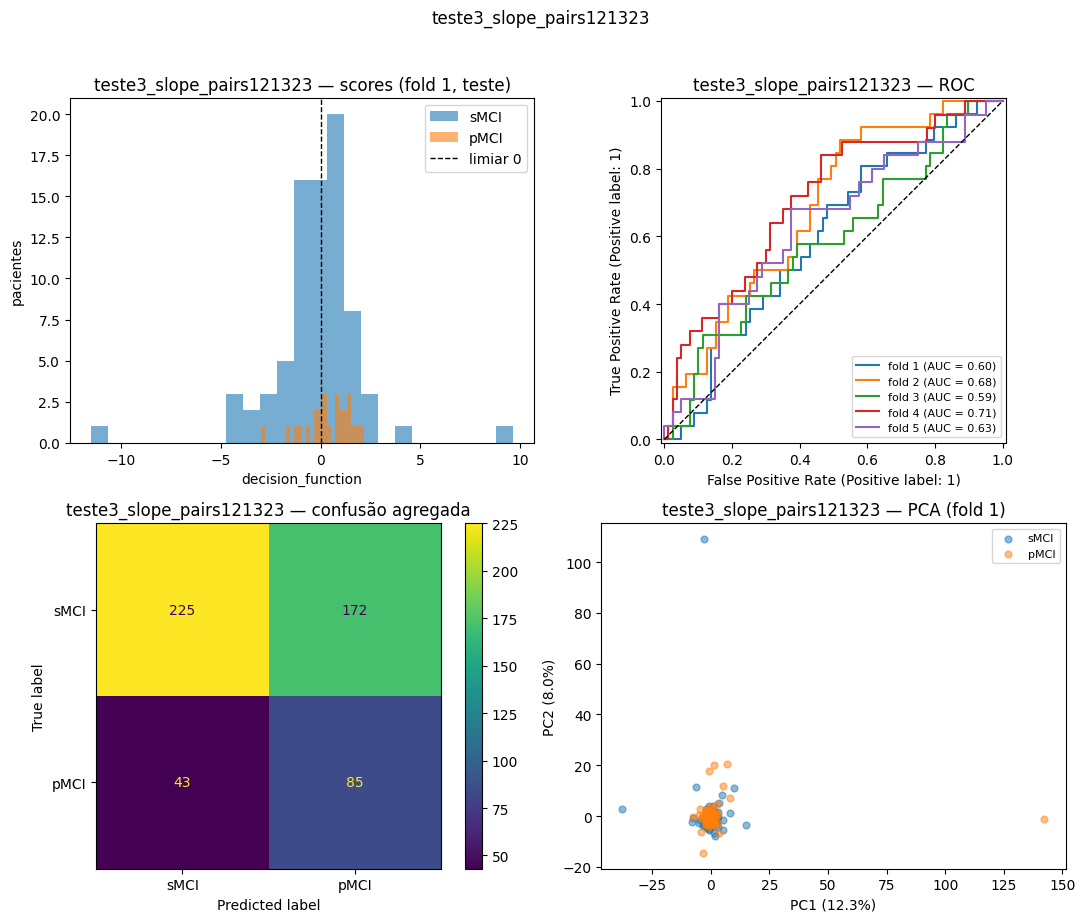

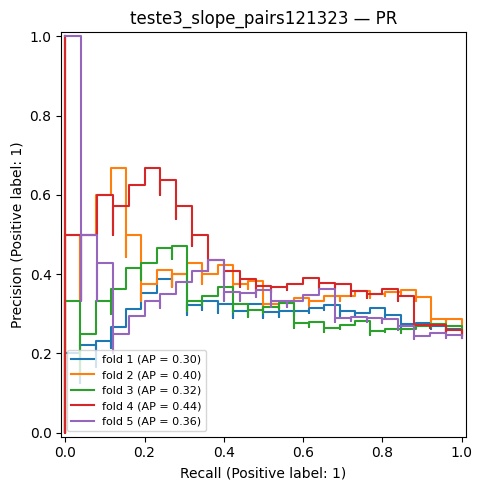

In [3]:
# --- Teste 3: 1 linha/paciente; Δ₁₂, Δ₁₃, Δ₂₃ (e slopes) por ROI×feature ---
import pandas as pd
# PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/all_features_patient_deltas.csv"
# PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/all_features_patient_deltas_hippocampus.csv"
PATH = "csvs/abordagem_4_sMCI_pMCI_extremos/features_displacement_article_hippocampus_temporal_deltas.csv"

FEATURE_KIND = "slope"  # "delta" | "slope" | "both"
TEMPORAL_PAIRS = ("12", "13", "23")  # pares i2−i1, i3−i1, i3−i2

meta = {"ID_PT", "GROUP", "SEX"}


def select_temporal_features(
    columns,
    meta_cols,
    *,
    kind: str = "delta",
    pairs: tuple[str, ...] = ("12", "13", "23"),
) -> list[str]:
    """Colunas de feature a partir do CSV do Teste 3 (_delta12_, _slope13_, etc.)."""
    feat = [c for c in columns if c not in meta_cols]
    if kind == "delta":
        tokens = [f"_delta{p}_" for p in pairs]
        feat = [c for c in feat if any(t in c for t in tokens)]
    elif kind == "slope":
        tokens = [f"_slope{p}_" for p in pairs]
        feat = [c for c in feat if any(t in c for t in tokens)]
    elif kind == "both":
        tokens = [f"_delta{p}_" for p in pairs] + [f"_slope{p}_" for p in pairs]
        feat = [c for c in feat if any(t in c for t in tokens)]
    else:
        raise ValueError(f"FEATURE_KIND inválido: {kind!r}")
    return feat


df = pd.read_csv(PATH)
feat_cols = select_temporal_features(
    df.columns, meta, kind=FEATURE_KIND, pairs=TEMPORAL_PAIRS
)
if not feat_cols:
    raise ValueError(
        f"Nenhuma coluna para kind={FEATURE_KIND!r}, pairs={TEMPORAL_PAIRS}. "
        "Rode a célula Teste 3 em features_selection.ipynb."
    )

X = df[feat_cols].to_numpy(float)
y = df["GROUP"].to_numpy(int)
pairs_tag = "".join(TEMPORAL_PAIRS)
test_name = f"teste3_{FEATURE_KIND}_pairs{pairs_tag}"

print(
    f"Teste 3 | {len(y)} pacientes | dim={X.shape[1]} | "
    f"kind={FEATURE_KIND} | pairs={TEMPORAL_PAIRS}"
)

results_t3, details_t3 = nested_cv_patient_level(
    X, y, test_name, collect_fold_details=True
)
print_summary(results_t3)
plot_cv_diagnostics(details_t3, test_name)


# Testes Xgboost



In [ ]:
# Funções compartilhadas — nested CV 5×5 + SVM + downsampling (só no treino)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.svm import LinearSVC

METRIC_COLS = [
    "auc", "auc_pr", "bal_acc", "mcc",
    "sens_pMCI", "spec_sMCI", "prec_pMCI", "f1_pMCI",
]
CLASS_NAMES = {0: "sMCI", 1: "pMCI"}
SEED = 42
K_OUT, K_IN = 5, 5
C_GRID = [1e-3, 0.01, 0.1, 1.0, 10.0]
# C_GRID = np.logspace(-4, 0, num=13).tolist()
CORR_THR = 0.95
VAR_THR = 0.01
USE_CORR_VAR = False         # correlação + variância por split
USE_SELECT_KBEST = False      # SelectKBest (após corr/var) por split
K_BEST_GRID = [30, 50, 100, 200]  # tunado no CV interno; ignorado se USE_SELECT_KBEST=False
SCALER = "standard"           # "standard" | "robust"
CLASS_WEIGHT = None           # None ou "balanced" (redundante com downsampling)
USE_DOWNSAMPLE = True         # balanceia sMCI/pMCI no treino de cada split
TUNE_THRESHOLD = True         # Youden (tpr−fpr) no CV interno → melhora bal_acc vs limiar 0
SVM_MAX_ITER = 200_000


def fold_metrics(y_true, scores, pred) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "auc": float(roc_auc_score(y_true, scores)),
        "auc_pr": float(average_precision_score(y_true, scores)),
        "bal_acc": float(balanced_accuracy_score(y_true, pred)),
        "mcc": float(matthews_corrcoef(y_true, pred)),
        "sens_pMCI": float(tp / (tp + fn)) if (tp + fn) else float("nan"),
        "spec_sMCI": float(tn / (tn + fp)) if (tn + fp) else float("nan"),
        "prec_pMCI": float(precision_score(y_true, pred, pos_label=1, zero_division=0)),
        "f1_pMCI": float(f1_score(y_true, pred, pos_label=1, zero_division=0)),
    }


# def clf(C: float) -> LinearSVC:
#     return LinearSVC(C=C, max_iter=75000, dual="auto", random_state=SEED)
def clf(C: float) -> LinearSVC:
    # dual=False é obrigatório quando usamos penalty='l1'
    return LinearSVC(
        penalty="l1",
        dual=False,
        C=C,
        max_iter=SVM_MAX_ITER,
        random_state=SEED,
        class_weight=CLASS_WEIGHT,
    )

def downsample_patient_indices(idx, y, seed: int) -> np.ndarray:
    """Mesmo nº de índices sMCI e pMCI no conjunto referenciado por idx."""
    idx = np.asarray(idx)
    rng = np.random.default_rng(seed)
    i0 = idx[y[idx] == 0]
    i1 = idx[y[idx] == 1]
    n = min(len(i0), len(i1))
    pick = np.concatenate([rng.choice(i0, n, replace=False), rng.choice(i1, n, replace=False)])
    rng.shuffle(pick)
    return pick


def train_indices(idx, y, seed: int) -> np.ndarray:
    if USE_DOWNSAMPLE:
        return downsample_patient_indices(idx, y, seed)
    return np.asarray(idx)


def tune_decision_threshold(y_true, scores) -> float:
    """Índice de Youden no CV interno: maximiza sens + spec − 1."""
    y_true = np.asarray(y_true, dtype=int)
    scores = np.asarray(scores, dtype=float)
    if len(np.unique(y_true)) < 2:
        return 0.0
    fpr, tpr, thr = roc_curve(y_true, scores)
    j = tpr - fpr
    return float(thr[int(np.argmax(j))])


def fit_fold_model(X_fit, y_fit, X_other, keep, C):
    X_fit_sel = apply_column_mask(X_fit, keep)
    X_other_sel = apply_column_mask(X_other, keep)
    X_fit_z, X_other_z = scale_train_val(X_fit_sel, X_other_sel)
    model = clf(C)
    model.fit(X_fit_z, y_fit)
    return model, X_fit_z, X_other_z


# --- Correlação + variância (sem SelectKBest) ---
def corr_keep_indices(X: np.ndarray, thr: float) -> np.ndarray:
    xf = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    if xf.shape[0] < 2:
        return np.arange(X.shape[1], dtype=int)
    c = np.corrcoef(xf.T)
    keep: list[int] = []
    for j in range(c.shape[0]):
        if all(not (np.isfinite(c[j, k]) and abs(c[j, k]) > thr) for k in keep):
            keep.append(j)
    return np.asarray(keep, dtype=int)


def var_keep_indices(X: np.ndarray, thr: float) -> np.ndarray:
    xf = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    vt = VarianceThreshold(threshold=thr)
    vt.fit(xf)
    return np.where(vt.get_support())[0]


def corr_var_keep(X_train: np.ndarray, corr_thr: float, var_thr: float) -> np.ndarray:
    """Máscara de colunas: só correlação + variância."""
    if not USE_CORR_VAR:
        return np.arange(X_train.shape[1], dtype=int)
    k_corr = corr_keep_indices(X_train, corr_thr)
    k_var = var_keep_indices(X_train[:, k_corr], var_thr)
    return k_corr[k_var]


# --- SelectKBest exclusivo (requer y; colunas já filtradas por corr/var) ---
def select_kbest_keep(X_train: np.ndarray, y_train: np.ndarray, k: int) -> np.ndarray:
    """Índices locais (0..n_cols-1) das colunas de X_train escolhidas por f_classif."""
    X = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
    n_cols = X.shape[1]
    if n_cols == 0:
        return np.arange(0, dtype=int)
    k = min(int(k), n_cols)
    if k < 1:
        return np.arange(n_cols, dtype=int)
    skb = SelectKBest(score_func=f_classif, k=k)
    skb.fit(X, np.asarray(y_train, dtype=int))
    return np.where(skb.get_support())[0]


def build_column_keep(X_train: np.ndarray, y_train: np.ndarray, k: int) -> np.ndarray:
    """Ordem: corr/var → SelectKBest (opcional) → índices no X original."""
    keep = corr_var_keep(X_train, CORR_THR, VAR_THR)
    if USE_SELECT_KBEST:
        k_local = select_kbest_keep(X_train[:, keep], y_train, k)
        keep = keep[k_local]
    return keep


def apply_column_mask(X: np.ndarray, keep: np.ndarray) -> np.ndarray:
    return X[:, keep]


def _make_scaler():
    if SCALER == "robust":
        return RobustScaler()
    if SCALER == "standard":
        return StandardScaler()
    raise ValueError(f"SCALER inválido: {SCALER!r}")


def scale_train_val(X_fit, X_other):
    scaler = _make_scaler()
    return scaler.fit_transform(X_fit), scaler.transform(X_other)


def _k_grid():
    return K_BEST_GRID if USE_SELECT_KBEST else [0]


def nested_cv_patient_level(
    X, y, test_name: str, *, collect_fold_details: bool = False
):
    """Testes 1 e 2: StratifiedKFold + corr/var + SelectKBest + z-score por split."""
    results = []
    fold_details: list[dict] = []
    outer = StratifiedKFold(K_OUT, shuffle=True, random_state=SEED)
    for fold, (tr, te) in enumerate(outer.split(X, y), start=1):
        best_C, best_k = C_GRID[0], K_BEST_GRID[0]
        best_inner_auc = -1.0
        inner = StratifiedKFold(K_IN, shuffle=True, random_state=SEED + fold)

        for k in _k_grid():
            for C in C_GRID:
                inner_aucs = []
                seed_extra = int(k) if USE_SELECT_KBEST else 0
                for in_tr, in_va in inner.split(X[tr], y[tr]):
                    keep = build_column_keep(X[tr][in_tr], y[tr][in_tr], k)
                    bal = train_indices(
                        in_tr, y[tr], SEED + fold + int(C * 1e4) + seed_extra
                    )
                    X_fit = apply_column_mask(X[tr][bal], keep)
                    X_va = apply_column_mask(X[tr][in_va], keep)
                    X_fit_z, X_va_z = scale_train_val(X_fit, X_va)

                    model = clf(C)
                    model.fit(X_fit_z, y[tr][bal])
                    if len(np.unique(y[tr][in_va])) > 1:
                        inner_aucs.append(
                            roc_auc_score(y[tr][in_va], model.decision_function(X_va_z))
                        )

                if inner_aucs and np.mean(inner_aucs) > best_inner_auc:
                    best_inner_auc = float(np.mean(inner_aucs))
                    best_C, best_k = C, k

        keep = build_column_keep(X[tr], y[tr], best_k)
        threshold = 0.0
        if TUNE_THRESHOLD:
            inner_scores, inner_y = [], []
            for in_tr, in_va in inner.split(X[tr], y[tr]):
                keep_in = build_column_keep(X[tr][in_tr], y[tr][in_tr], best_k)
                bal_in = train_indices(in_tr, y[tr], SEED + fold + 9000)
                model_in, _, X_va_z = fit_fold_model(
                    X[tr][bal_in], y[tr][bal_in], X[tr][in_va], keep_in, best_C
                )
                inner_scores.append(model_in.decision_function(X_va_z))
                inner_y.append(y[tr][in_va])
            threshold = tune_decision_threshold(
                np.concatenate(inner_y), np.concatenate(inner_scores)
            )

        bal = train_indices(tr, y, SEED + fold)
        model, X_fit_z, X_te_z = fit_fold_model(
            X[bal], y[bal], X[te], keep, best_C
        )
        scores = model.decision_function(X_te_z)
        pred = (scores >= threshold).astype(int)

        row = {
            "test": test_name,
            "fold": fold,
            "best_C": best_C,
            "best_k": int(best_k) if USE_SELECT_KBEST else None,
            "threshold": threshold,
            "n_features": int(len(keep)),
            "n_train_bal": len(bal),
            "n_test": len(te),
            "n_test_pMCI": int(y[te].sum()),
            **fold_metrics(y[te], scores, pred),
        }
        results.append(row)
        if collect_fold_details:
            fold_details.append({
                "fold": fold,
                "best_C": best_C,
                "best_k": best_k,
                "threshold": threshold,
                "y_test": np.asarray(y[te], dtype=int),
                "scores": np.asarray(scores, dtype=float),
                "pred": np.asarray(pred, dtype=int),
                "X_fit_z": X_fit_z,
                "X_te_z": X_te_z,
                "y_fit": np.asarray(y[bal], dtype=int),
            })

    df = pd.DataFrame(results)
    if collect_fold_details:
        return df, fold_details
    return df


# --- Gráficos de diagnóstico (teste externo por fold) ---
def plot_score_histogram(y, scores, *, title="Scores no teste", ax=None, threshold=0.0):
    ax = ax or plt.gca()
    ax.hist(scores[y == 0], bins=25, alpha=0.6, label=CLASS_NAMES[0])
    ax.hist(scores[y == 1], bins=25, alpha=0.6, label=CLASS_NAMES[1])
    ax.axvline(threshold, color="k", linestyle="--", linewidth=1, label=f"limiar {threshold:.3f}")
    ax.set_xlabel("decision_function")
    ax.set_ylabel("pacientes")
    ax.set_title(title)
    ax.legend()
    return ax


def plot_roc_all_folds(fold_details, *, title="ROC — folds externos", ax=None):
    ax = ax or plt.gca()
    for fd in fold_details:
        if len(np.unique(fd["y_test"])) < 2:
            continue
        RocCurveDisplay.from_predictions(
            fd["y_test"], fd["scores"], ax=ax, name=f"fold {fd['fold']}"
        )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=8)
    return ax


def plot_pr_all_folds(fold_details, *, title="PR — folds externos", ax=None):
    ax = ax or plt.gca()
    for fd in fold_details:
        if len(np.unique(fd["y_test"])) < 2:
            continue
        PrecisionRecallDisplay.from_predictions(
            fd["y_test"], fd["scores"], ax=ax, name=f"fold {fd['fold']}"
        )
    ax.set_title(title)
    ax.legend(loc="lower left", fontsize=8)
    return ax


def plot_confusion_aggregate(fold_details, *, title="Confusão agregada (teste)", ax=None):
    y_all = np.concatenate([fd["y_test"] for fd in fold_details])
    pred_all = np.concatenate([fd["pred"] for fd in fold_details])
    ax = ax or plt.gca()
    ConfusionMatrixDisplay.from_predictions(
        y_all, pred_all, display_labels=[CLASS_NAMES[0], CLASS_NAMES[1]], ax=ax
    )
    ax.set_title(title)
    return ax


def plot_pca_fold(fd, *, title=None, ax=None):
    pca = PCA(n_components=2, random_state=SEED)
    Z_fit = pca.fit_transform(fd["X_fit_z"])
    Z_te = pca.transform(fd["X_te_z"])
    Z = np.vstack([Z_fit, Z_te])
    y_plot = np.concatenate([fd["y_fit"], fd["y_test"]])

    ax = ax or plt.gca()
    for label in (0, 1):
        m = y_plot == label
        ax.scatter(Z[m, 0], Z[m, 1], alpha=0.5, s=24, label=CLASS_NAMES[label])
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title(title or f"PCA — fold externo {fd['fold']}")
    ax.legend(fontsize=8)
    return ax


def plot_cv_diagnostics(fold_details, test_name, *, hist_fold=1, pca_fold=1):
    fd_hist = next(fd for fd in fold_details if fd["fold"] == hist_fold)
    fd_pca = next(fd for fd in fold_details if fd["fold"] == pca_fold)

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    plot_score_histogram(
        fd_hist["y_test"], fd_hist["scores"],
        title=f"{test_name} — scores (fold {hist_fold}, teste)", ax=axes[0, 0],
    )
    plot_roc_all_folds(fold_details, title=f"{test_name} — ROC", ax=axes[0, 1])
    plot_confusion_aggregate(
        fold_details, title=f"{test_name} — confusão agregada", ax=axes[1, 0],
    )
    plot_pca_fold(fd_pca, title=f"{test_name} — PCA (fold {pca_fold})", ax=axes[1, 1])
    fig.suptitle(test_name, fontsize=12, y=1.02)
    fig.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(figsize=(6, 5))
    plot_pr_all_folds(fold_details, title=f"{test_name} — PR", ax=ax2)
    fig2.tight_layout()
    plt.show()


def print_summary(df: pd.DataFrame) -> None:
    print(f"\n=== {df['test'].iloc[0]} ===")
    display(df)
    print("\nResumo (média ± desvio entre folds):")
    for col in METRIC_COLS:
        print(f"  {col:12s}: {df[col].mean():.3f} ± {df[col].std():.3f}")
